# Autoencoder Clustering (Separate Notebook)

This notebook runs the Autoencoder-based clustering pipeline only.
K-means baseline is in `AI/K_mean.ipynb`.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, v_measure_score

TF_AVAILABLE = True
try:
    import tensorflow as tf
    from tensorflow.keras import layers, Model
except Exception as e:
    TF_AVAILABLE = False
    TF_IMPORT_ERROR = str(e)

sns.set_theme(style='whitegrid')
np.random.seed(42)

if not TF_AVAILABLE:
    print('TensorFlow not available. PCA fallback will be used for latent features.')
    print(f'Reason: {TF_IMPORT_ERROR}')

In [3]:
df_loaded = pd.read_csv(os.path.join('data', 'data_preprocessed.csv'))
gender_labels = df_loaded['Gender']
X_scaled = df_loaded[['Age', 'Annual_Income', 'Spending_Score']]
raw_df = pd.read_csv(os.path.join('data', 'Shopping Mall Customer Segmentation Data .csv'))
reference_labels = raw_df['Gender'].astype(str)

print(f'Scaled feature matrix shape: {X_scaled.shape}')
print(f'Raw data shape: {raw_df.shape}')
X_scaled.head()

Scaled feature matrix shape: (15079, 3)
Raw data shape: (15079, 5)


,Age,Annual_Income,Spending_Score
0,-0.666667,0.465394,0.775510
1,0.111111,0.835265,0.897959
2,0.222222,-0.421253,0.510204
3,-0.861111,-0.591304,0.122449
4,-0.833333,0.490409,0.510204


In [4]:
if TF_AVAILABLE:
    tf.random.set_seed(42)

    input_dim = X_scaled.shape[1]
    input_layer = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(8, activation='relu')(input_layer)
    encoded = layers.Dense(2, activation='linear', name='latent')(encoded)
    decoded = layers.Dense(8, activation='relu')(encoded)
    decoded = layers.Dense(input_dim, activation='linear')(decoded)

    autoencoder = Model(inputs=input_layer, outputs=decoded)
    encoder = Model(inputs=input_layer, outputs=autoencoder.get_layer('latent').output)

    autoencoder.compile(optimizer='adam', loss='mse')
    history = autoencoder.fit(
        X_scaled,
        X_scaled,
        epochs=30,
        batch_size=256,
        validation_split=0.2,
        verbose=0
    )

    latent_features = encoder.predict(X_scaled, verbose=0)
    latent_df = pd.DataFrame(latent_features, columns=['Latent1', 'Latent2'])

    print('Autoencoder training completed.')
    print(f"Final train loss: {history.history['loss'][-1]:.6f}")
    print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")
else:
    latent_pca = PCA(n_components=2, random_state=42)
    latent_features = latent_pca.fit_transform(X_scaled)
    latent_df = pd.DataFrame(latent_features, columns=['Latent1', 'Latent2'])
    print('Using PCA fallback latent features.')

Autoencoder training completed.
Final train loss: 0.075708
Final validation loss: 0.076617


In [5]:
latent_rows = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = model.fit_predict(X_scaled)


    latent_rows.append({
        'k': k,
        'inertia': model.inertia_,
        'silhouette': silhouette_score(latent_df, labels),
        'v_measure_vs_gender': v_measure_score(reference_labels, labels)
    })

latent_scores = pd.DataFrame(latent_rows)
latent_scores

,k,inertia,silhouette,v_measure_vs_gender
0,2,11465.326072,0.281108,0.000009
1,3,9196.395351,0.124573,0.000212
2,4,7296.111165,0.229374,0.000044
3,5,6128.002106,0.085433,0.000075
4,6,5054.030963,0.136423,0.000120
5,7,4437.788754,0.133305,0.000093
6,8,3842.138984,0.091160,0.000089
7,9,3603.406979,0.080529,0.000083
8,10,3431.901673,0.058172,0.000068


    k       inertia  silhouette  v_measure_vs_gender
0   2  11465.326072    0.245219             0.000009
1   3   9196.395351    0.238797             0.000212
2   4   7296.111165    0.264055             0.000044
3   5   6128.002106    0.266534             0.000075
4   6   5054.030963    0.288885             0.000120
5   7   4437.788754    0.279830             0.000093
6   8   3842.138984    0.279378             0.000089
7   9   3603.406979    0.288389             0.000083
8  10   3431.901673    0.276412             0.000068
Best k: 6
Inertia: 5054.03
Silhouette: 0.2889
V-measure vs Gender: 0.0001


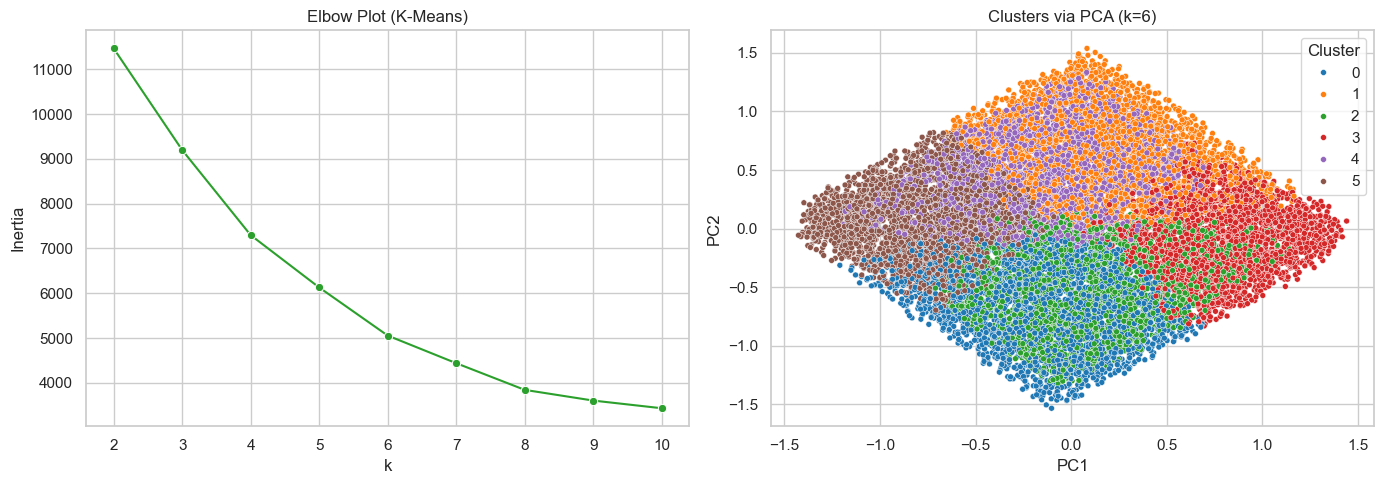

In [8]:
# ✅ Everything uses X_scaled consistently
latent_rows = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = model.fit_predict(X_scaled)          # ✅ X_scaled not latent_df

    latent_rows.append({
        'k': k,
        'inertia': model.inertia_,
        'silhouette': silhouette_score(X_scaled, labels),     # ✅ X_scaled
        'v_measure_vs_gender': v_measure_score(reference_labels, labels)  # ✅ kept
    })

latent_scores = pd.DataFrame(latent_rows)
print(latent_scores)

best_k_latent = int(latent_scores.loc[latent_scores['silhouette'].idxmax(), 'k'])

kmeans_latent = KMeans(n_clusters=best_k_latent, random_state=42, n_init='auto')
latent_labels = kmeans_latent.fit_predict(X_scaled)           # ✅ X_scaled

latent_clustered_df = X_scaled.copy()
latent_clustered_df['Gender'] = gender_labels.values
latent_clustered_df['Cluster'] = latent_labels

latent_inertia = kmeans_latent.inertia_
latent_silhouette = silhouette_score(X_scaled, latent_labels)         # ✅ X_scaled
latent_v_measure = v_measure_score(reference_labels, latent_labels)   # ✅ kept

print(f'Best k: {best_k_latent}')
print(f'Inertia: {latent_inertia:.2f}')
print(f'Silhouette: {latent_silhouette:.4f}')
print(f'V-measure vs Gender: {latent_v_measure:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=latent_scores, x='k', y='inertia', marker='o', ax=axes[0], color='#2ca02c')
axes[0].set_title('Elbow Plot (K-Means)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

pca_viz = PCA(n_components=2, random_state=42)
X_viz = pd.DataFrame(pca_viz.fit_transform(X_scaled), columns=['PC1', 'PC2'])
X_viz['Cluster'] = latent_labels

sns.scatterplot(data=X_viz, x='PC1', y='PC2', hue='Cluster',
                palette='tab10', s=18, ax=axes[1], legend='full')
axes[1].set_title(f'Clusters via PCA (k={best_k_latent})')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [6]:
output_path = os.path.join('data', 'autoencoder_clustered_data.csv')
latent_clustered_df.to_csv(output_path, index=False)
print(f'Saved autoencoder clustered data to: {output_path}')

Saved autoencoder clustered data to: data\autoencoder_clustered_data.csv
